# econ-charts Demo & Test Notebook

This notebook demonstrates the features of the `econ-charts` library for creating sharp, professional economic charts.

## Features Demonstrated

1. **Chart Generation**: Single and multi-subplot charts
2. **Scale Alignment**: Proper axis scaling for all data points
3. **Hover Tooltips**: Interactive data point display
4. **Zoom Functionality**: Drag-to-zoom and double-click reset
5. **Dark Theme**: Modern dark color scheme
6. **Customization**: Custom colors and styling

In [1]:
# Install dependencies if needed
import sys
sys.path.insert(0, '../src')

from datetime import datetime, timedelta
import math
import random

from econ_charts import EconChart, DEFAULT_COLORS
from IPython.display import Image, display, HTML

## Data Generation Functions

These functions generate realistic-looking economic data for demonstration.

In [2]:
def generate_gdp_data(start_year=2000, years=24):
    """Generate sample GDP growth data."""
    random.seed(42)
    dates, values = [], []
    for year in range(start_year, start_year + years):
        for quarter in range(1, 5):
            month = (quarter - 1) * 3 + 1
            dates.append(datetime(year, month, 1))
            growth = 2.5 + math.sin(year / 3) * 1.5 + random.uniform(-0.5, 0.5)
            if 2008 <= year <= 2009:
                growth = -3 + random.uniform(-2, 1)
            elif year == 2020 and quarter <= 2:
                growth = -8 + random.uniform(-2, 2)
            values.append(growth)
    return dates, values

def generate_inflation_data(start_year=2000, years=24):
    """Generate sample inflation data."""
    random.seed(43)
    dates, values = [], []
    for year in range(start_year, start_year + years):
        for month in range(1, 13):
            dates.append(datetime(year, month, 1))
            inflation = 2.5 + math.sin(year / 4) * 1.0 + random.uniform(-0.3, 0.3)
            if year >= 2021:
                inflation = 5 + (year - 2021) * 2 + random.uniform(-0.5, 0.5)
            if year >= 2023:
                inflation = 6 - (year - 2022) * 1.5 + random.uniform(-0.5, 0.5)
            values.append(max(0, inflation))
    return dates, values

def generate_unemployment_data(start_year=2000, years=24):
    """Generate sample unemployment data."""
    random.seed(44)
    dates, values = [], []
    for year in range(start_year, start_year + years):
        for month in range(1, 13):
            dates.append(datetime(year, month, 1))
            rate = 5 + math.sin(year / 5) * 1.5 + random.uniform(-0.2, 0.2)
            if 2008 <= year <= 2010:
                rate = 7 + (year - 2008) * 1.5 + random.uniform(-0.3, 0.3)
            elif year == 2020:
                rate = 8 + random.uniform(-0.5, 2)
            values.append(max(3, rate))
    return dates, values

def generate_stock_data(start_year=2020, years=4):
    """Generate sample stock price data."""
    random.seed(45)
    dates, values = [], []
    price = 100
    for year in range(start_year, start_year + years):
        for month in range(1, 13):
            for day in [1, 8, 15, 22]:
                try:
                    dates.append(datetime(year, month, day))
                    price = price * (1 + random.uniform(-0.02, 0.025))
                    values.append(price)
                except ValueError:
                    pass
    return dates, values

def generate_interest_rate_data(start_year=2000, years=24):
    """Generate sample interest rate data."""
    random.seed(46)
    dates, values = [], []
    for year in range(start_year, start_year + years):
        for month in range(1, 13):
            dates.append(datetime(year, month, 1))
            if year < 2008:
                rate = 4 + math.sin(year / 2) * 2
            elif 2008 <= year <= 2015:
                rate = 0.25
            elif 2015 < year <= 2019:
                rate = (year - 2015) * 0.5
            elif 2020 <= year <= 2021:
                rate = 0.25
            else:
                rate = min(5.5, (year - 2021) * 2)
            values.append(max(0, rate + random.uniform(-0.1, 0.1)))
    return dates, values

## 1. Single Subplot Chart

A simple chart showing GDP growth rate over time.

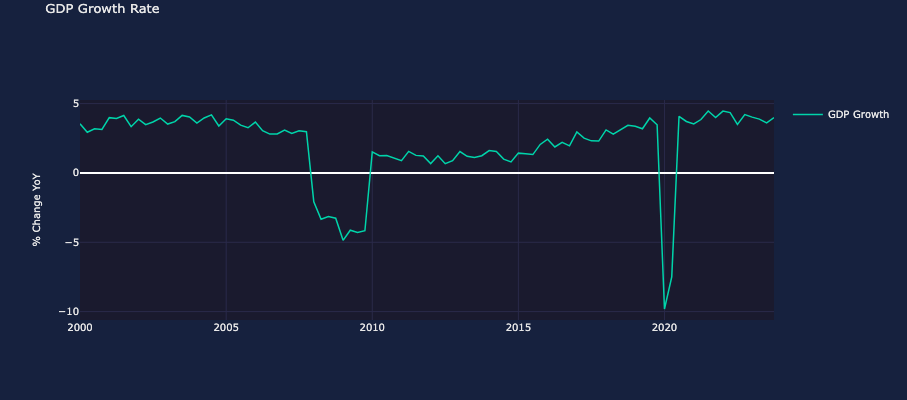

In [3]:
dates, values = generate_gdp_data()

chart = EconChart(num_rows=1, height=400)
chart.add_line(row=1, x=dates, y=values, name='GDP Growth', color='#00d4aa')
chart.set_title('GDP Growth Rate')
chart.set_yaxis(row=1, title='% Change YoY')
chart.add_hline(row=1, y=0)
chart.enable_unified_spikeline()
chart.show()

## 2. Multi-Subplot Chart

A chart with three synchronized subplots showing GDP, Inflation, and Unemployment.

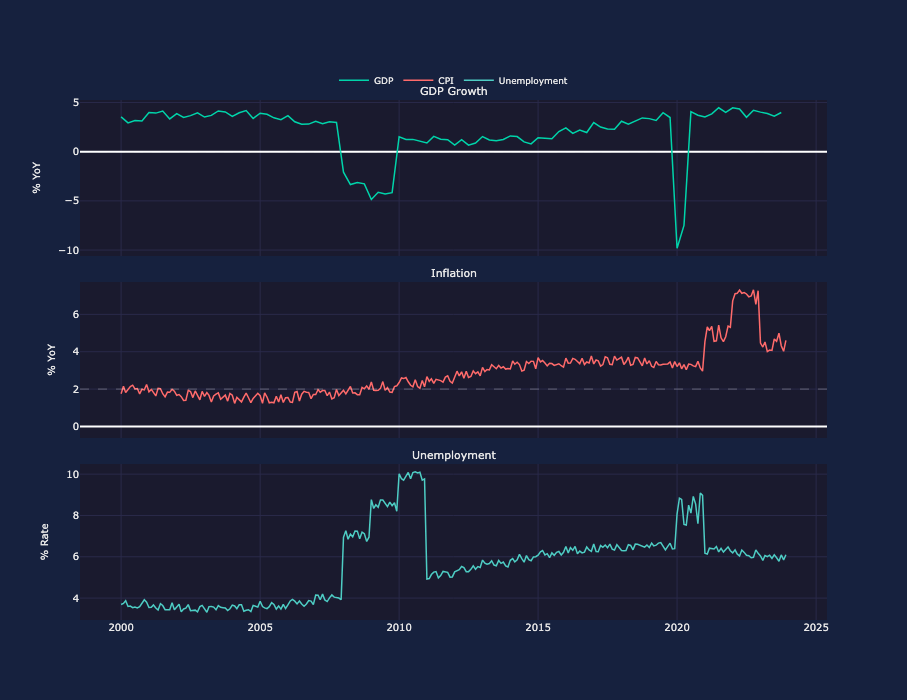

In [4]:
gdp_dates, gdp_values = generate_gdp_data()
inf_dates, inf_values = generate_inflation_data()
unemp_dates, unemp_values = generate_unemployment_data()

chart = EconChart(
    num_rows=3,
    subplot_titles=('GDP Growth', 'Inflation', 'Unemployment'),
    height=700,
)

chart.add_line(row=1, x=gdp_dates, y=gdp_values, name='GDP', color='#00d4aa')
chart.add_line(row=2, x=inf_dates, y=inf_values, name='CPI', color='#ff6b6b')
chart.add_line(row=3, x=unemp_dates, y=unemp_values, name='Unemployment', color='#4ecdc4')

chart.set_yaxis(row=1, title='% YoY')
chart.set_yaxis(row=2, title='% YoY')
chart.set_yaxis(row=3, title='% Rate')

chart.add_hline(row=1, y=0)
chart.add_hline(row=2, y=2.0)  # 2% inflation target

chart.set_legend(orientation='h', position='top')
chart.enable_unified_spikeline()
chart.show()

## 3. Logarithmic Scale Chart

Stock prices often look better on a log scale to show percentage changes more accurately.

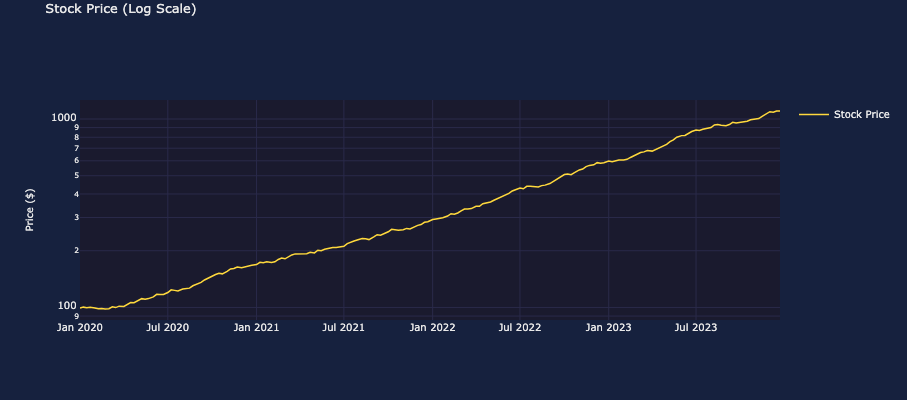

In [5]:
dates, values = generate_stock_data()
# Create exponential growth for log scale demo
exp_values = [v * (1.1 ** (i/10)) for i, v in enumerate(values)]

chart = EconChart(num_rows=1, height=400)
chart.add_line(row=1, x=dates, y=exp_values, name='Stock Price', color='#ffd93d')
chart.set_yaxis(row=1, title='Price ($)', scale_type='log')
chart.set_title('Stock Price (Log Scale)')
chart.enable_unified_spikeline()
chart.show()

## 4. Multiple Series Comparison

Comparing GDP growth and interest rates on the same chart.

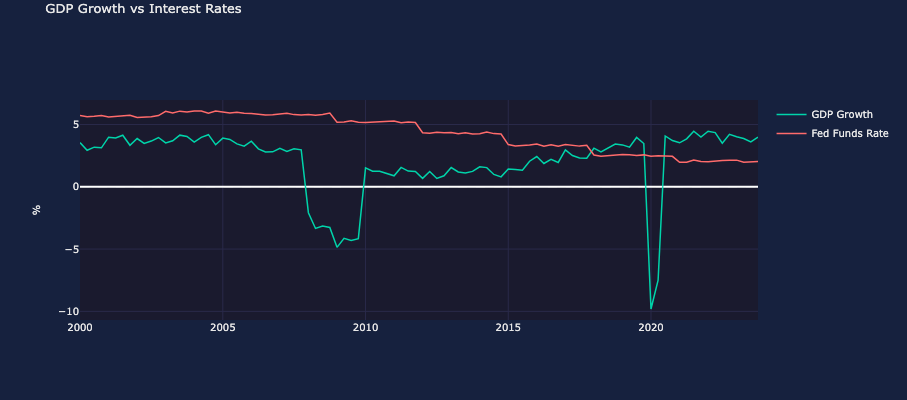

In [6]:
dates, gdp = generate_gdp_data()
_, rates = generate_interest_rate_data()
min_len = min(len(dates), len(rates))
dates = dates[:min_len]
gdp = gdp[:min_len]
rates = rates[:min_len]

chart = EconChart(num_rows=1, height=400)
chart.add_line(row=1, x=dates, y=gdp, name='GDP Growth', color='#00d4aa')
chart.add_line(row=1, x=dates, y=rates, name='Fed Funds Rate', color='#ff6b6b')
chart.set_title('GDP Growth vs Interest Rates')
chart.set_yaxis(row=1, title='%')
chart.add_hline(row=1, y=0)
chart.enable_unified_spikeline()
chart.show()

## 5. Custom Color Theme

You can customize the color scheme for different visual styles.

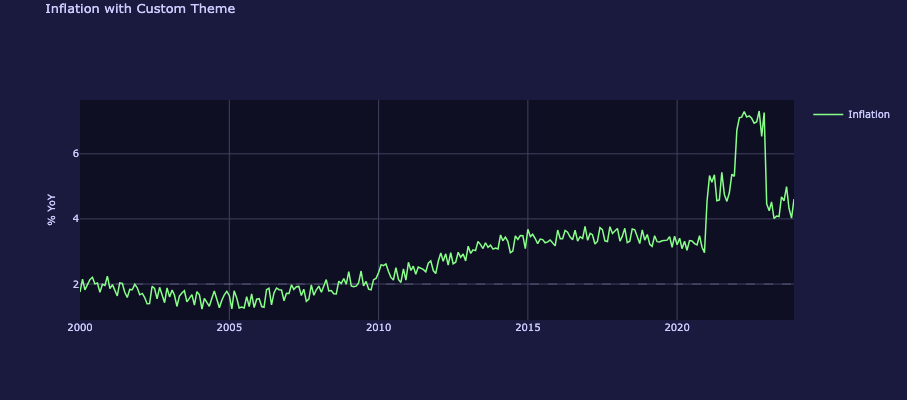

In [7]:
dates, values = generate_inflation_data()

custom_colors = {
    'background': '#0f0f23',
    'paper': '#1a1a3e',
    'grid': '#404060',
    'text': '#ccccff',
    'spike': 'rgba(200, 200, 255, 0.5)',
    'zero_line': 'rgba(200, 200, 255, 0.3)',
}

chart = EconChart(num_rows=1, height=400, colors=custom_colors)
chart.add_line(row=1, x=dates, y=values, name='Inflation', color='#88ff88')
chart.set_title('Inflation with Custom Theme')
chart.set_yaxis(row=1, title='% YoY')
chart.add_hline(row=1, y=2.0)
chart.enable_unified_spikeline()
chart.show()

## 6. Scatter Plot with Markers

Sometimes you want to show individual data points rather than lines.

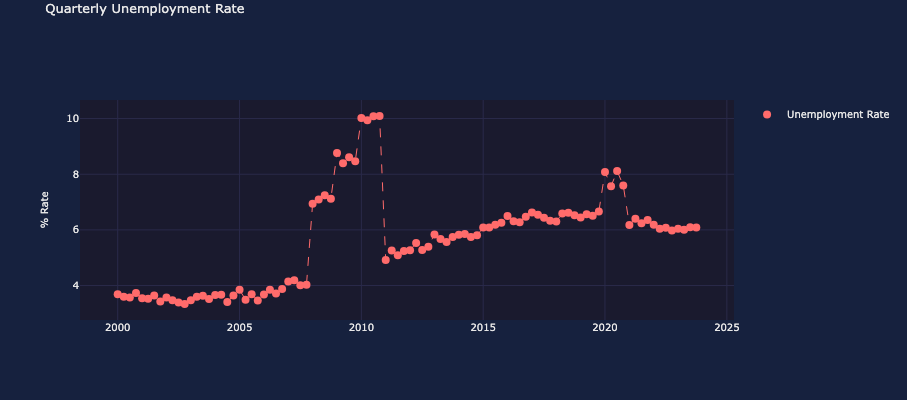

In [8]:
# Quarterly unemployment data points
dates, values = generate_unemployment_data()
quarterly_dates = dates[::3]  # Every 3rd month
quarterly_values = values[::3]

chart = EconChart(num_rows=1, height=400)
chart.add_scatter(
    row=1, 
    x=quarterly_dates, 
    y=quarterly_values, 
    name='Unemployment Rate', 
    color='#ff6b6b',
    marker_size=8
)
chart.add_line(
    row=1,
    x=quarterly_dates,
    y=quarterly_values,
    name='Trend',
    color='#ff6b6b',
    width=1,
    dash='dash',
    showlegend=False
)
chart.set_title('Quarterly Unemployment Rate')
chart.set_yaxis(row=1, title='% Rate')
chart.enable_unified_spikeline()
chart.show()

---

## Test Screenshots

The following screenshots were captured during automated testing using Playwright.

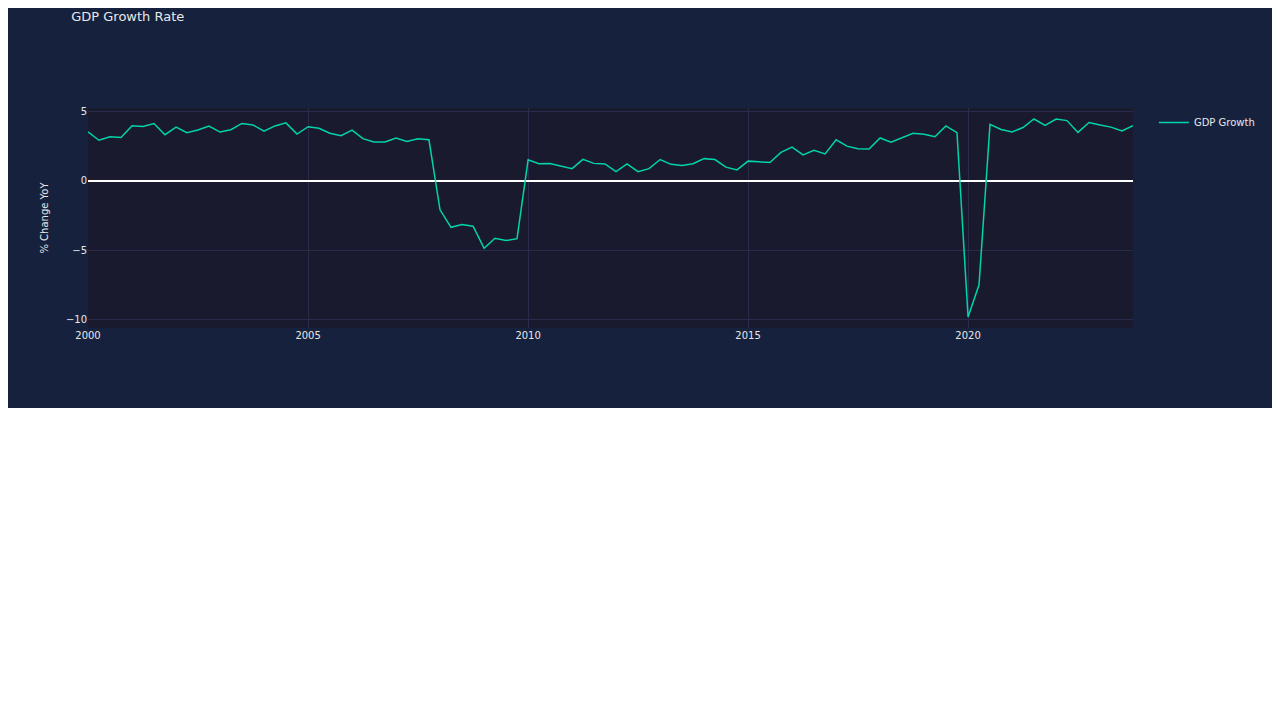

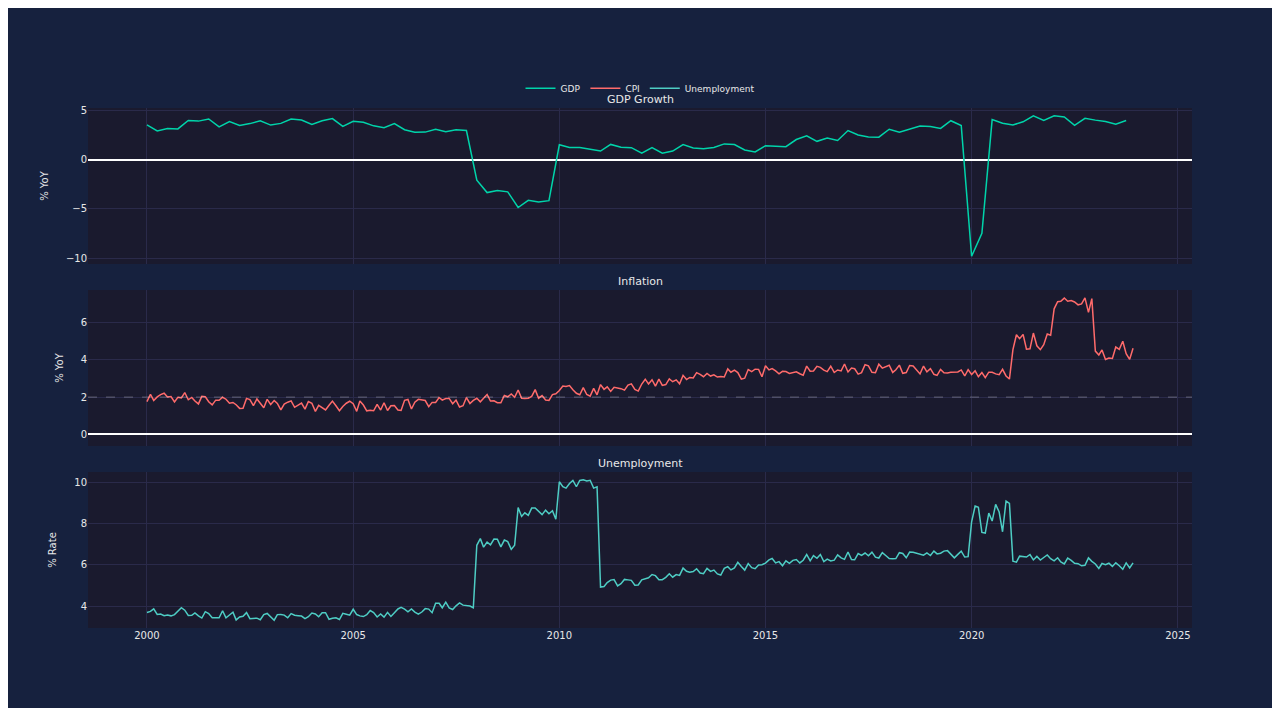

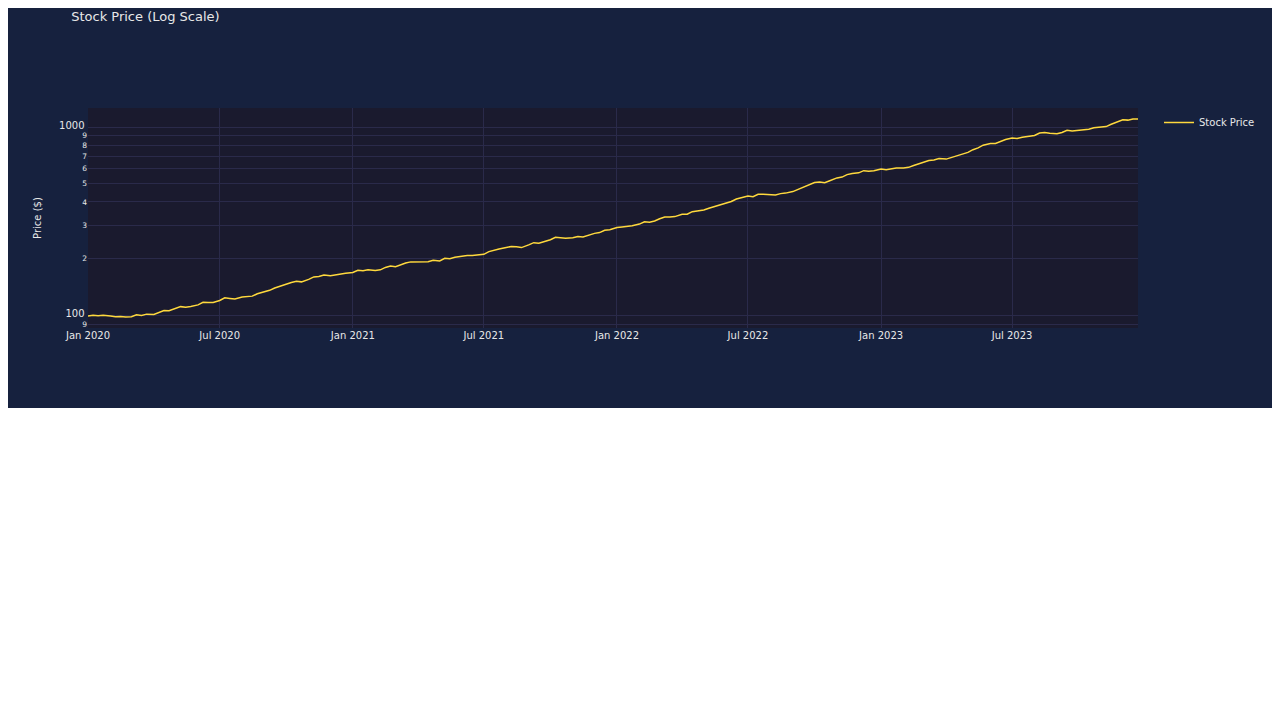

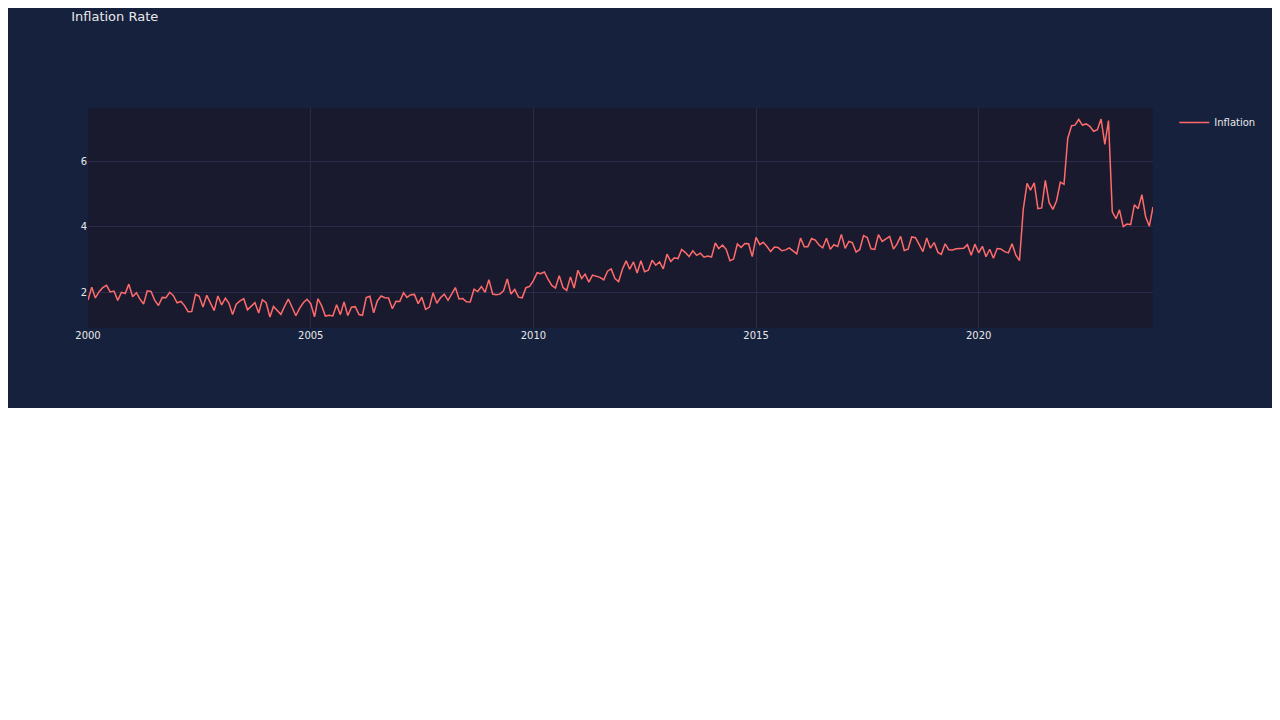

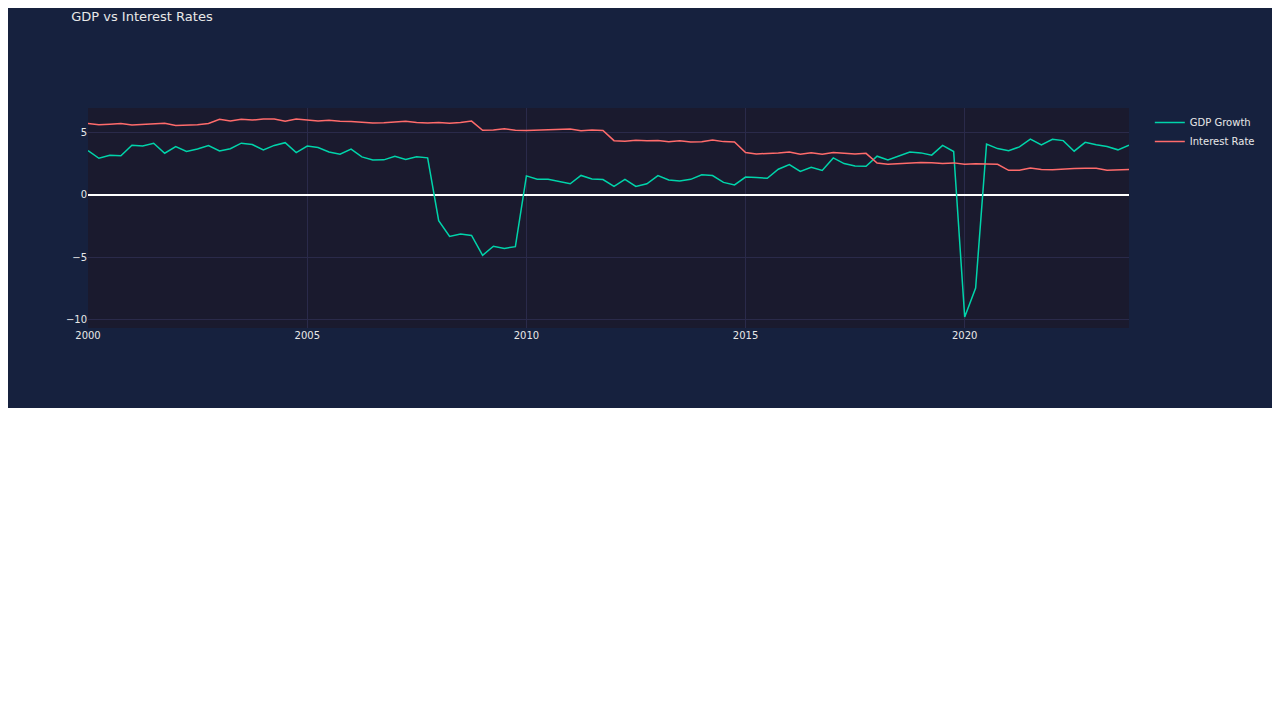

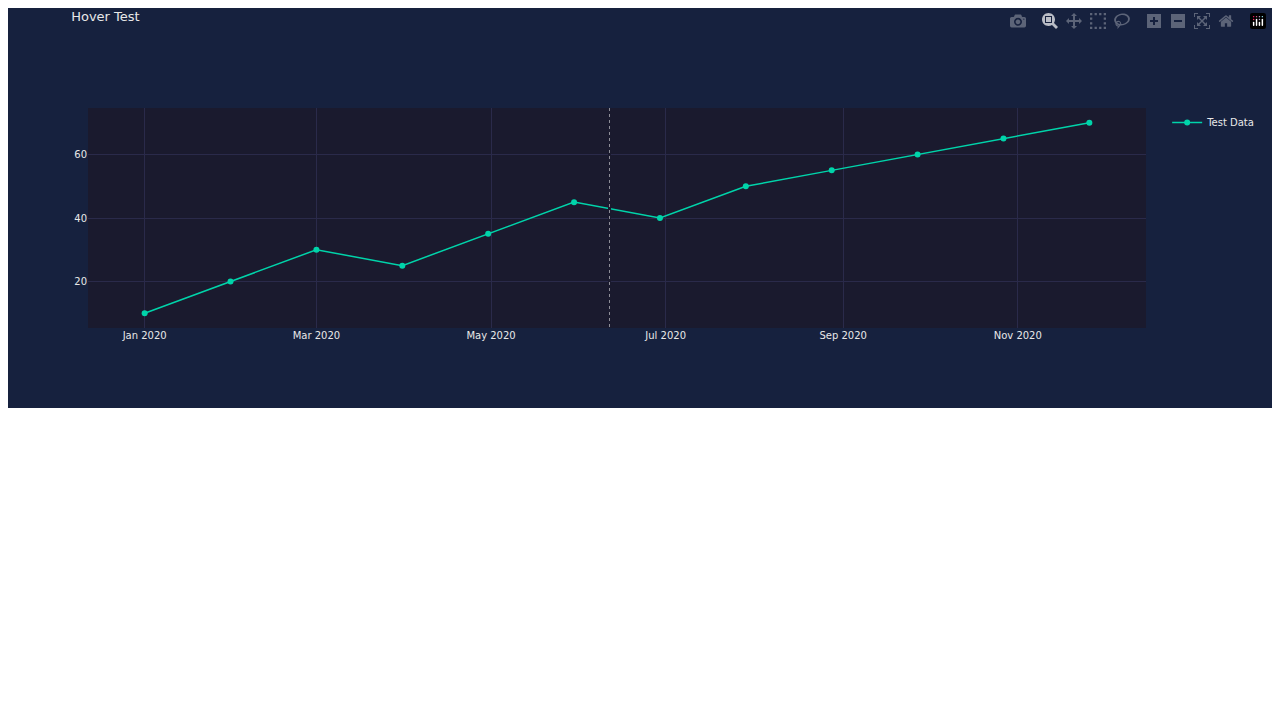

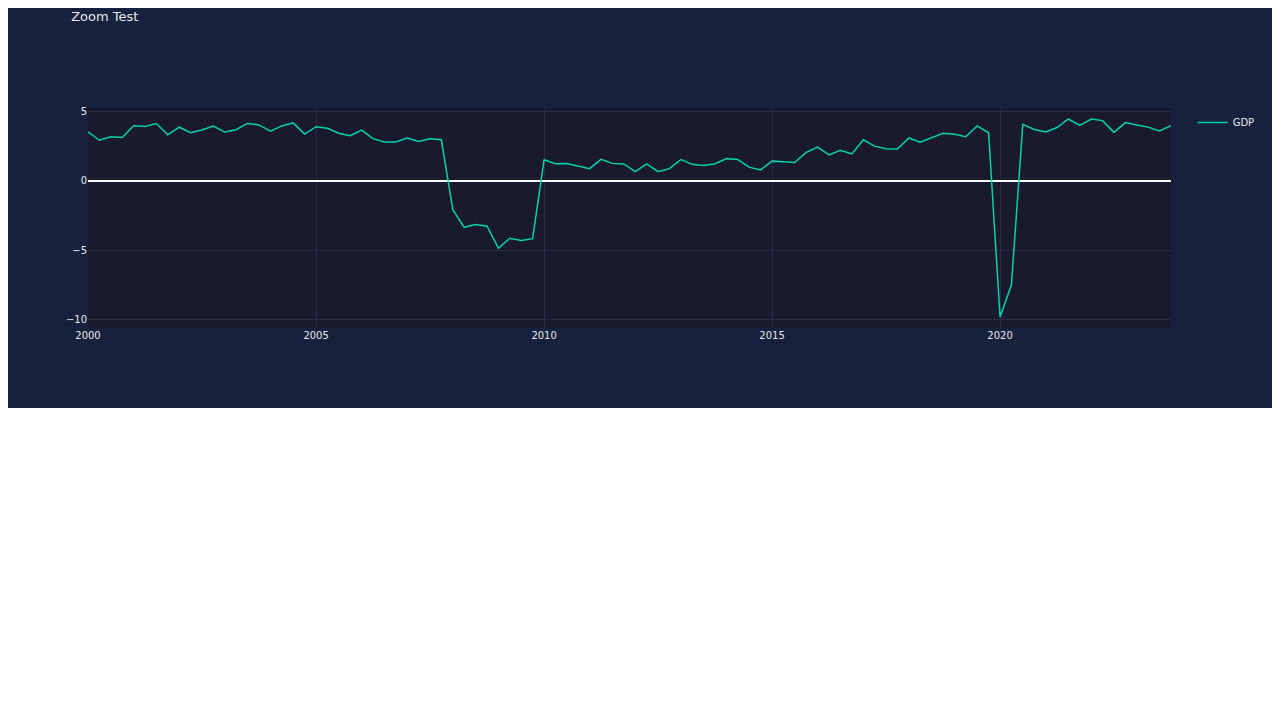

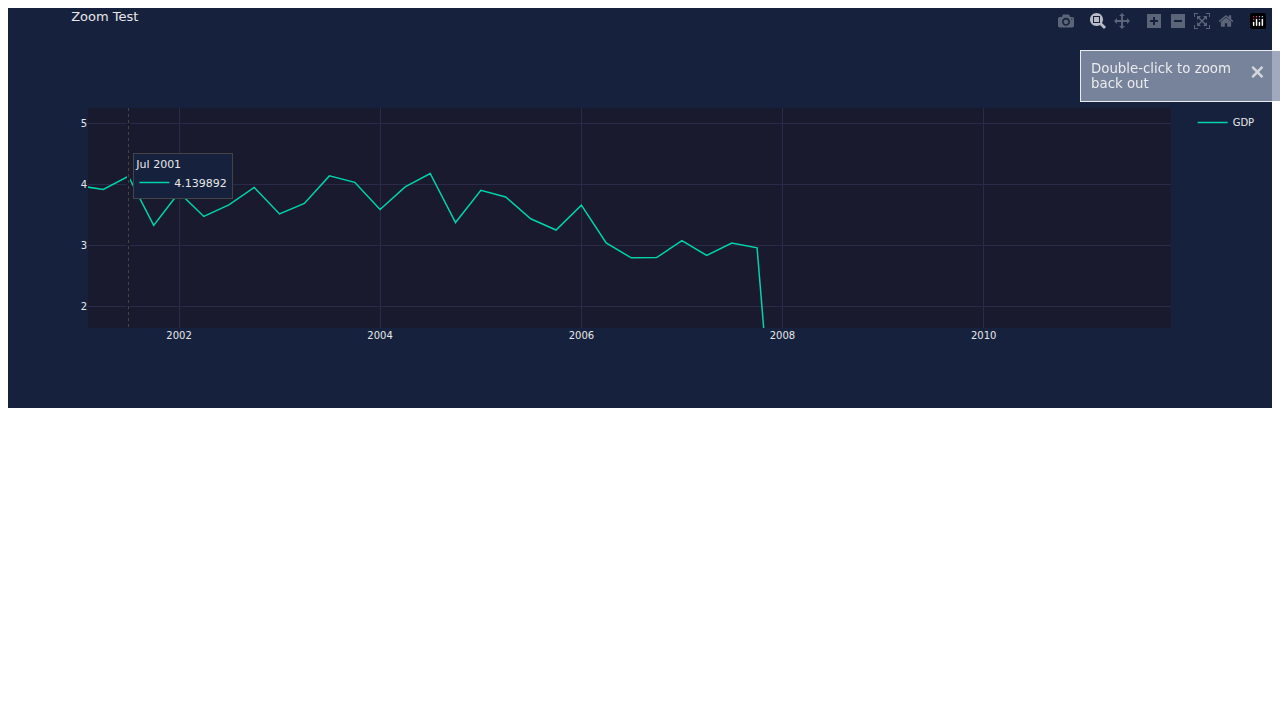

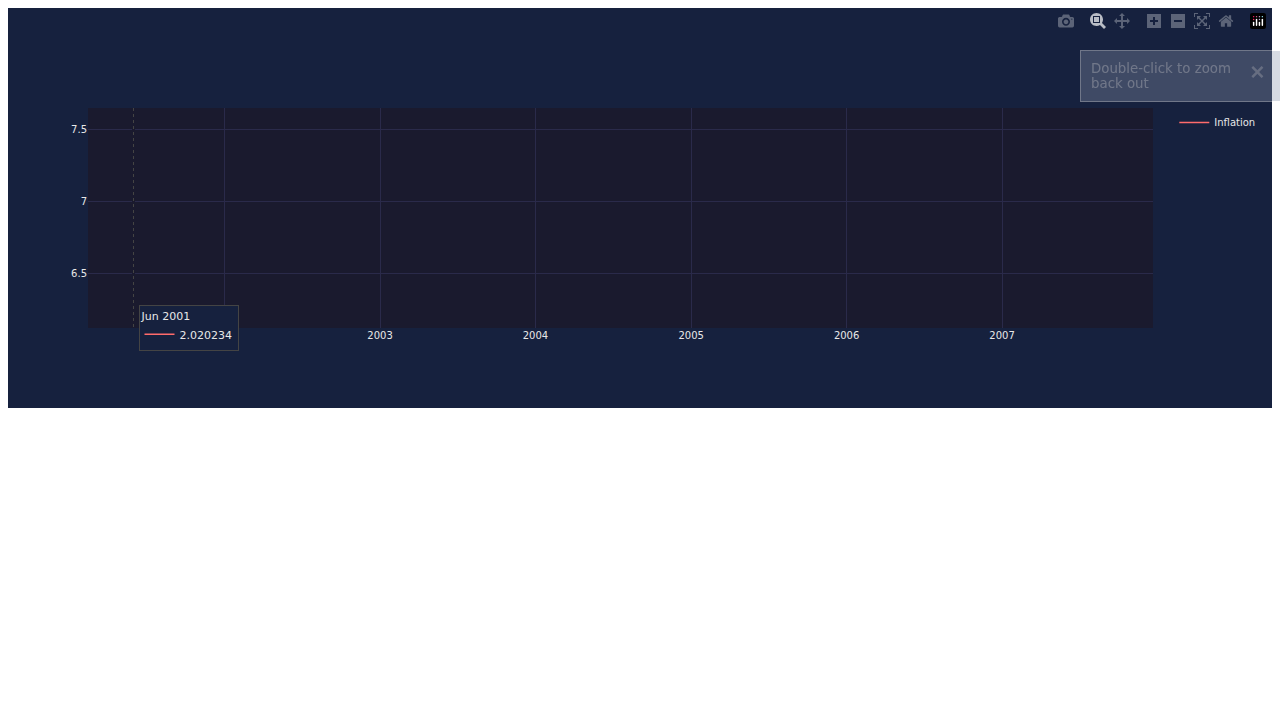

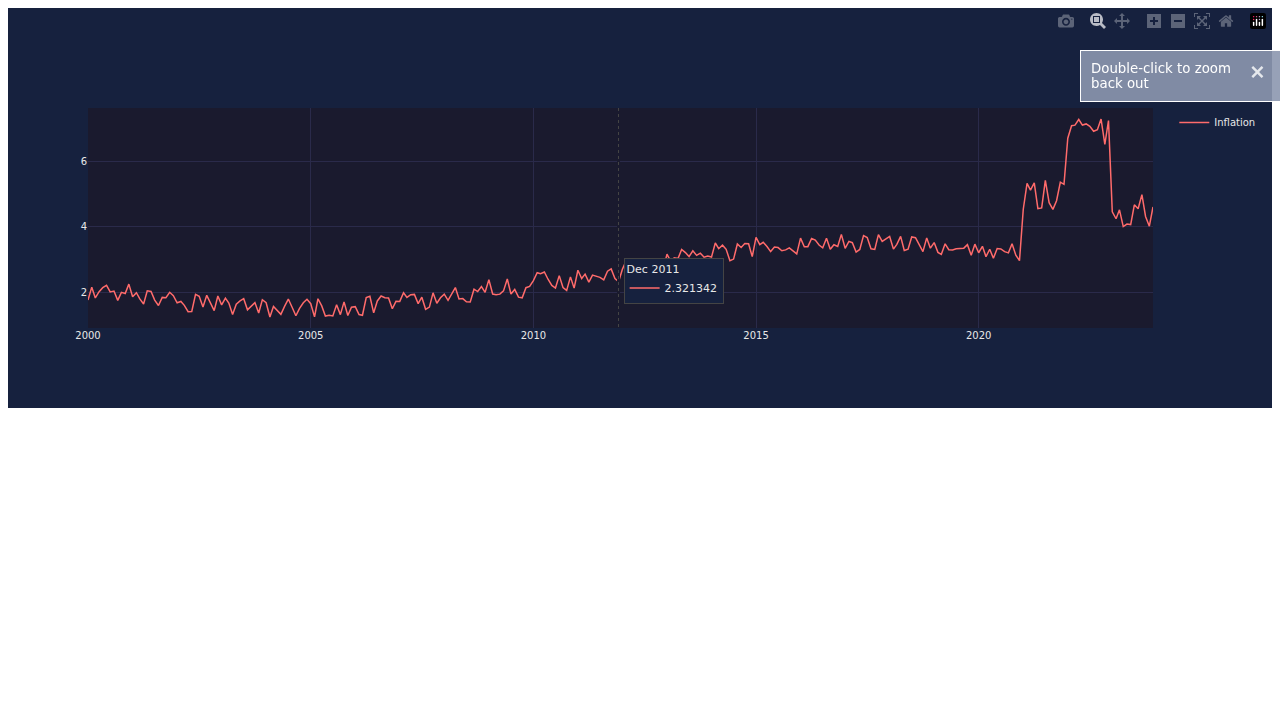

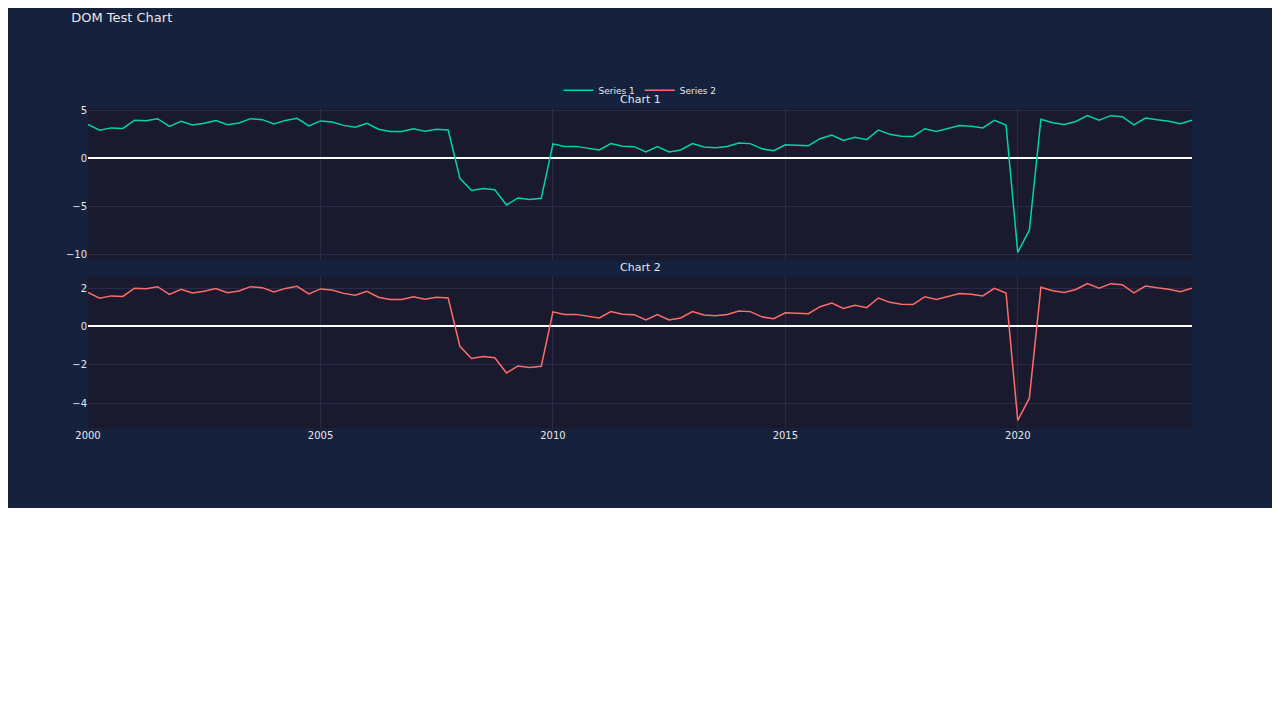

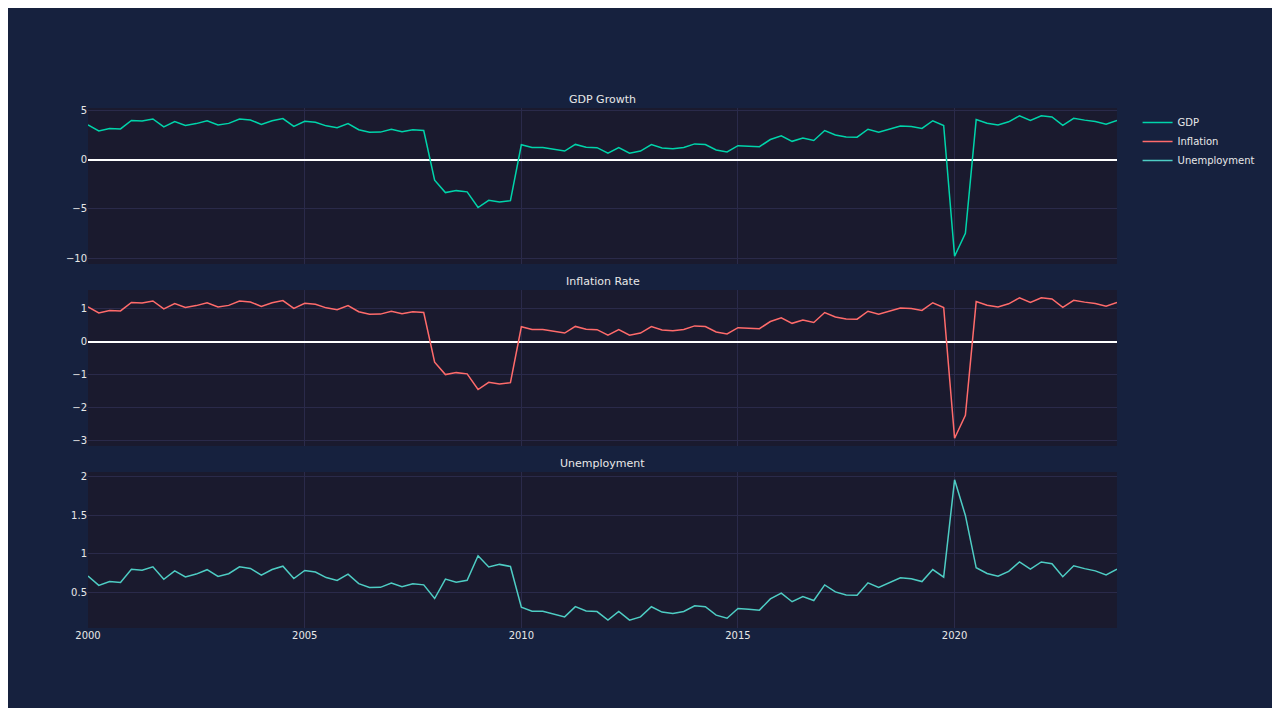

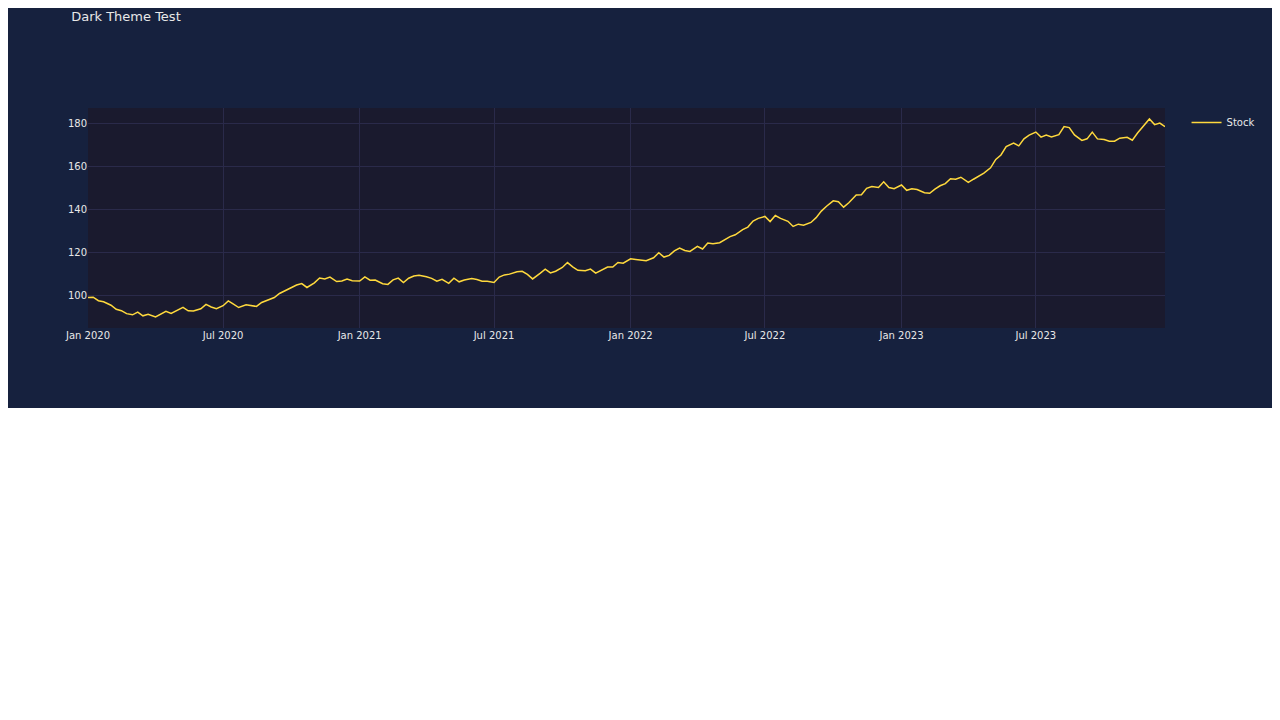

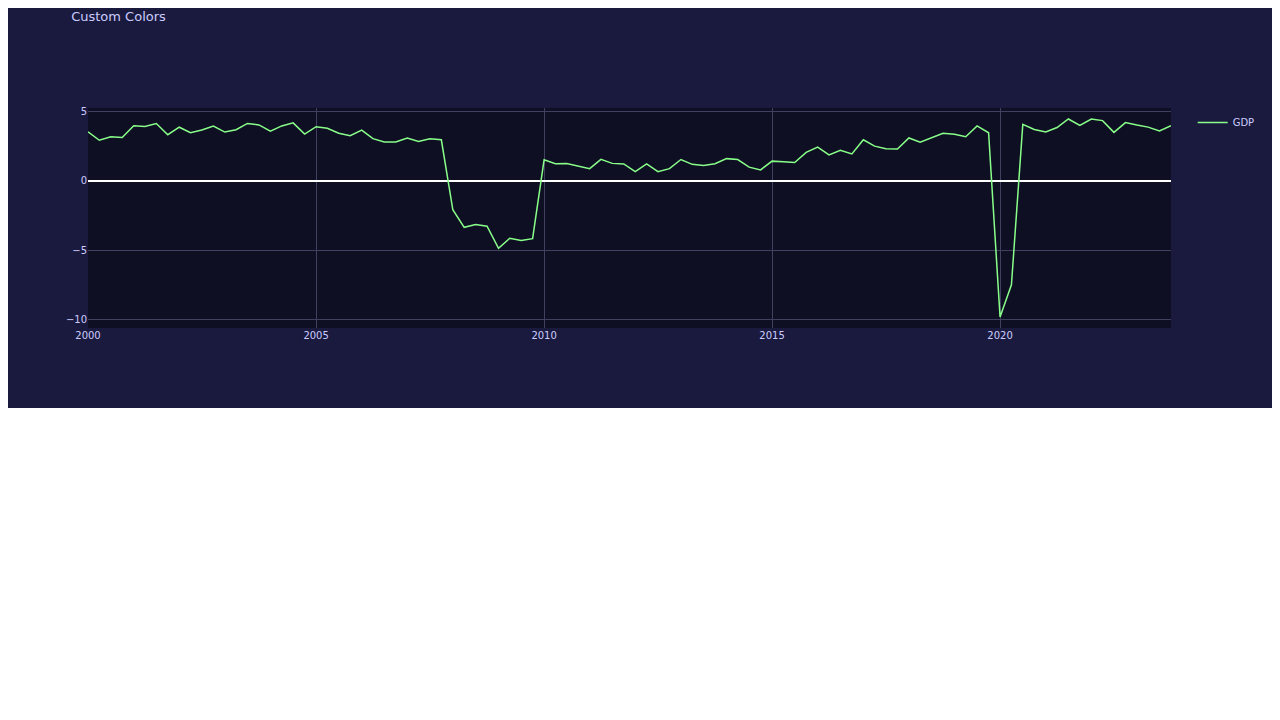

In [9]:
from pathlib import Path
from IPython.display import Image, display, HTML

screenshots_dir = Path('../test_output/screenshots')

if screenshots_dir.exists():
    screenshots = {
        'Single Subplot Chart': 'single_subplot.png',
        'Multi-Subplot Chart': 'multi_subplot.png',
        'Log Scale Chart': 'log_scale.png',
        'Scale Alignment Test': 'scale_alignment.png',
        'Multi-Series Scale Test': 'multi_series_scale.png',
        'Hover Tooltip Test': 'hover_tooltip.png',
        'Zoom Before': 'zoom_before.png',
        'Zoom After': 'zoom_after.png',
        'Zoom Reset (Zoomed)': 'zoom_reset_zoomed.png',
        'Zoom Reset (After Double-Click)': 'zoom_reset_after.png',
        'DOM Structure Test': 'dom_structure.png',
        'Subplot Titles Test': 'subplot_titles.png',
        'Dark Theme Test': 'dark_theme.png',
        'Custom Colors Test': 'custom_colors.png',
    }
    
    for title, filename in screenshots.items():
        path = screenshots_dir / filename
        if path.exists():
            display(HTML(f'<h3>{title}</h3>'))
            display(Image(filename=str(path), width=800))
        else:
            print(f"Screenshot not found: {filename}")
else:
    print("Screenshots directory not found. Run the tests first with: pytest tests/test_charts_visual.py")

## Test Summary

The automated tests verify:

1. **Chart Generation Tests**
   - Single subplot chart creation
   - Multi-subplot chart creation with 3 rows
   - Logarithmic scale chart

2. **Scale Alignment Tests**
   - Y-axis range encompasses all data points
   - Multiple series on same subplot scale correctly

3. **Hover Tooltip Tests**
   - Hover displays tooltip over chart
   - Data values are accurately passed to Plotly

4. **Zoom Functionality Tests**
   - Drag-to-zoom changes axis range
   - Double-click resets zoom to original range

5. **DOM Structure Tests**
   - Essential Plotly elements exist (SVG, axes, legend)
   - Subplot titles are rendered correctly

6. **Color Theme Tests**
   - Dark theme colors applied correctly
   - Custom color schemes work as expected

## Interactive Features

All charts in this notebook support:

- **Hover**: Move your mouse over the chart to see data values
- **Zoom**: Click and drag to select an area to zoom in
- **Pan**: After zooming, drag to pan around
- **Reset**: Double-click to reset the view
- **Legend Toggle**: Click legend items to show/hide series